In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# Linear Regression

In [2]:
df = pd.read_csv("../data/FINAL_DF.csv")

In [3]:
df.head()

,Geography,LocYear,% >= HS,% >= Bachelor's,"Pov for 25yo<=, <HS","Pov for 25<=, >=Bachelor's",GeoFIPS,HFR,SNAP_rate,DPI_rate,PI_rate
0,0400000US01,AL2010,0.821,0.219,0.300,0.041,1000,0.456,0.147621,0.082011,0.089287
1,0400000US02,AK2010,0.910,0.279,0.177,0.028,2000,0.611,0.132925,0.128447,0.138935
2,0400000US04,AZ2010,0.856,0.259,0.301,0.046,4000,0.346,0.139955,0.085180,0.092639
3,0400000US05,AR2010,0.829,0.195,0.267,0.039,5000,0.493,0.142676,0.077484,0.084426
4,0400000US06,CA2010,0.807,0.301,0.253,0.049,6000,0.174,0.087893,0.115410,0.129771


In [4]:
X = df[["% >= HS", "% >= Bachelor's", "Pov for 25yo<=, <HS", 
                    "SNAP_rate", "DPI_rate", "PI_rate"]] 

In [5]:
y = df["HFR"]

In [6]:
model = LinearRegression()

In [7]:
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
r_sq = model.score(X, y)
print(f"coefficient of determination: {r_sq}")

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': abs(model.coef_)
}).sort_values(by='Importance', ascending=False)

print(importance_df)

coefficient of determination: 0.6115496285526327
               Feature  Importance
4             DPI_rate   12.027910
5              PI_rate   11.234479
0              % >= HS    2.340249
1      % >= Bachelor's    1.555581
2  Pov for 25yo<=, <HS    1.013790
3            SNAP_rate    0.779303


Now without DPI_rate

In [9]:
X = df[["% >= HS", "% >= Bachelor's", "Pov for 25yo<=, <HS", 
                    "SNAP_rate", "PI_rate"]] 
y = df["HFR"]
model = LinearRegression()
model.fit(X, y)

r_sq = model.score(X, y)
print(f"coefficient of determination: {r_sq}")

importance_df2 = pd.DataFrame({
    'Feature': X.columns,
    'LinearReg': abs(model.coef_)
}).sort_values(by='LinearReg', ascending=False)

importance_df2

coefficient of determination: 0.5919085723335016


,Feature,LinearReg
0,% >= HS,2.402364
1,% >= Bachelor's,1.880572
4,PI_rate,1.279294
3,SNAP_rate,0.866187
2,"Pov for 25yo<=, <HS",0.814288


# Single Linear Regression

In [10]:
def r2_scores(X, y):
    r2_dict = dict()
    for col_name in X:
        X2 = X[[col_name]]
        model = LinearRegression()
        model.fit(X2, y)
        r_sq = model.score(X2, y)
        r2_dict[col_name] = r_sq
        r_sq = None
    return r2_dict

In [11]:
single_scores = r2_scores(X, y)

In [12]:
single_scores

{'% >= HS': 0.009766193382809818,
 "% >= Bachelor's": 0.3491291089083367,
 'Pov for 25yo<=, <HS': 0.040661220695324074,
 'SNAP_rate': 0.005490702335183673,
 'PI_rate': 0.3068977174271347}

In [13]:
single_lr = pd.DataFrame(list(single_scores.items()), columns=['Feature', 'SingleLinearReg'])
single_lr

,Feature,SingleLinearReg
0,% >= HS,0.009766
1,% >= Bachelor's,0.349129
2,"Pov for 25yo<=, <HS",0.040661
3,SNAP_rate,0.005491
4,PI_rate,0.306898


In [14]:
import matplotlib.pyplot as plt

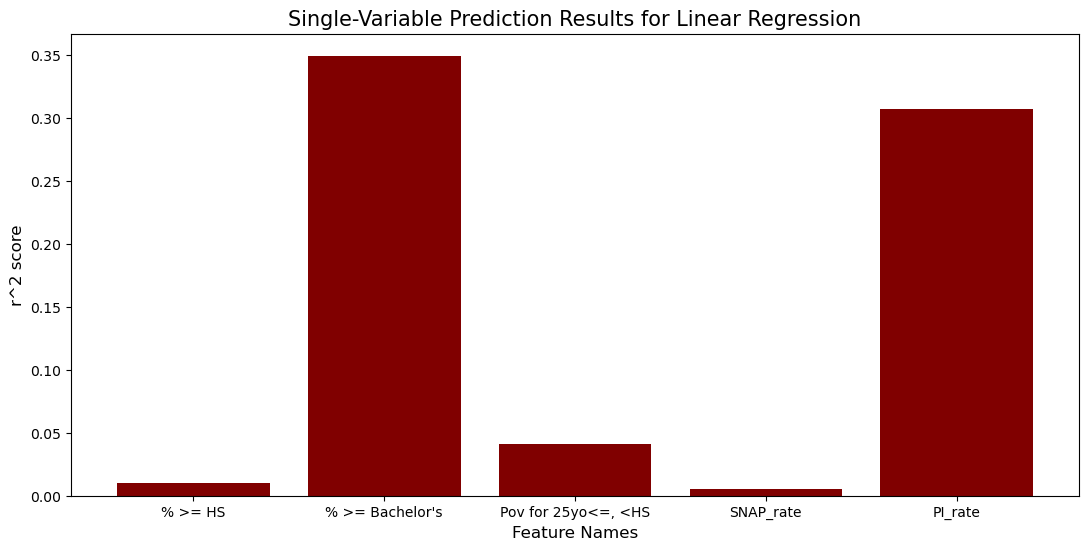

In [15]:
plt.figure(figsize=(13, 6))
plt.bar(single_scores.keys(), single_scores.values(), color="maroon")
plt.xlabel("Feature Names", fontsize=12)
plt.ylabel("r^2 score", fontsize=12)
plt.xticks(fontsize=10)
plt.title("Single-Variable Prediction Results for Linear Regression", fontsize=15)
plt.show()

# Permutation Feature Importance

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor

In [17]:
X = df[["% >= HS", "% >= Bachelor's", "Pov for 25yo<=, <HS", 
                    "SNAP_rate", "DPI_rate", "PI_rate"]] 
y = df["HFR"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42)

rf = RandomForestRegressor(random_state=42).fit(X_train, y_train)
print(f"Model Score: {rf.score(X_test, y_test)}")

r = permutation_importance(rf, X_test, y_test,
                           n_repeats=30,
                           random_state=0, scoring='r2')

column_names_list = X.columns.tolist()

for i in r.importances_mean.argsort()[::-1]:
    print(f"{column_names_list[i]:<8}" + ': '
            f"{r.importances_mean[i]:.3f}"
            f" +/- {r.importances_std[i]:.3f}")
    
feature_importance_df = pd.DataFrame({'Feature': column_names_list, 'Permutation': r.importances_mean})    
print("Feature importance:\n", feature_importance_df)
feature_importance_df

Model Score: 0.6022946483409709
% >= Bachelor's: 1.095 +/- 0.174
% >= HS : 0.461 +/- 0.095
PI_rate : 0.156 +/- 0.039
DPI_rate: 0.040 +/- 0.017
SNAP_rate: 0.023 +/- 0.014
Pov for 25yo<=, <HS: 0.019 +/- 0.015
Feature importance:
                Feature  Permutation
0              % >= HS     0.461267
1      % >= Bachelor's     1.094912
2  Pov for 25yo<=, <HS     0.019045
3            SNAP_rate     0.023083
4             DPI_rate     0.040179
5              PI_rate     0.155748


,Feature,Permutation
0,% >= HS,0.461267
1,% >= Bachelor's,1.094912
2,"Pov for 25yo<=, <HS",0.019045
3,SNAP_rate,0.023083
4,DPI_rate,0.040179
5,PI_rate,0.155748


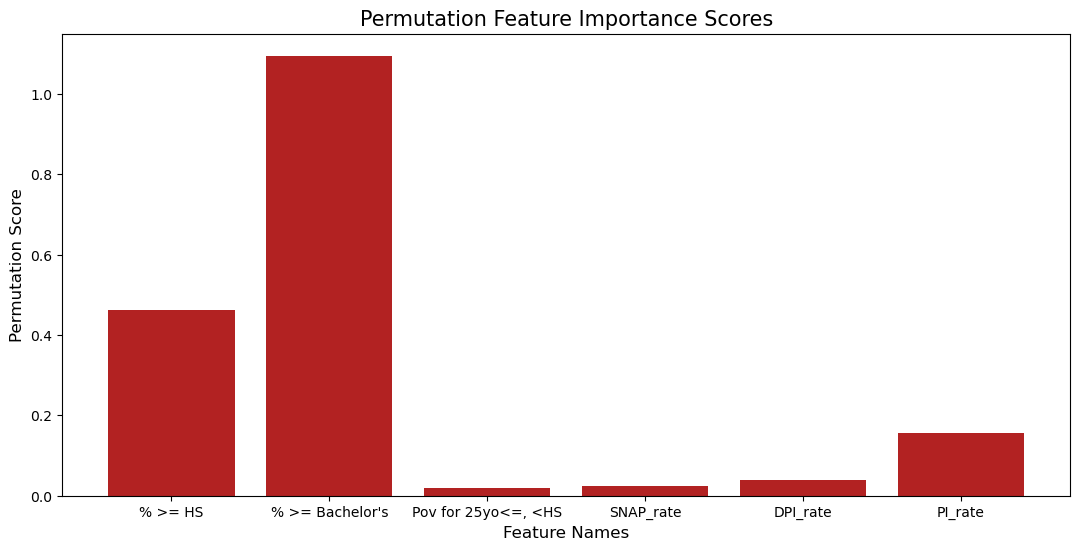

In [19]:
plt.figure(figsize=(13, 6))
plt.bar(feature_importance_df["Feature"], feature_importance_df["Permutation"], color="firebrick")
plt.xlabel("Feature Names", fontsize=12)
plt.ylabel("Permutation Score", fontsize=12)
plt.xticks(fontsize=10)
plt.title("Permutation Feature Importance Scores", fontsize=15)
plt.show()

Running it again with no DPI_rate

In [20]:
X = df[["% >= HS", "% >= Bachelor's", "Pov for 25yo<=, <HS", 
                    "SNAP_rate", "PI_rate"]] 
y = df["HFR"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42)

rf = RandomForestRegressor(random_state=42).fit(X_train, y_train)
print(f"Model Score: {rf.score(X_test, y_test)}")

r = permutation_importance(rf, X_test, y_test,
                           n_repeats=30,
                           random_state=0, scoring='r2')

column_names_list = X.columns.tolist()

for i in r.importances_mean.argsort()[::-1]:
    print(f"{column_names_list[i]:<8}" + ': '
            f"{r.importances_mean[i]:.3f}"
            f" +/- {r.importances_std[i]:.3f}")
    
feature_importance_df = pd.DataFrame({'Feature': column_names_list, 'Permutation': r.importances_mean})    
print("Feature importance:\n", feature_importance_df)
feature_importance_df

Model Score: 0.5974127798037477
% >= Bachelor's: 1.106 +/- 0.174
% >= HS : 0.450 +/- 0.095
PI_rate : 0.370 +/- 0.067
SNAP_rate: 0.023 +/- 0.013
Pov for 25yo<=, <HS: 0.022 +/- 0.017
Feature importance:
                Feature  Permutation
0              % >= HS     0.450088
1      % >= Bachelor's     1.105856
2  Pov for 25yo<=, <HS     0.022015
3            SNAP_rate     0.022964
4              PI_rate     0.370231


,Feature,Permutation
0,% >= HS,0.450088
1,% >= Bachelor's,1.105856
2,"Pov for 25yo<=, <HS",0.022015
3,SNAP_rate,0.022964
4,PI_rate,0.370231


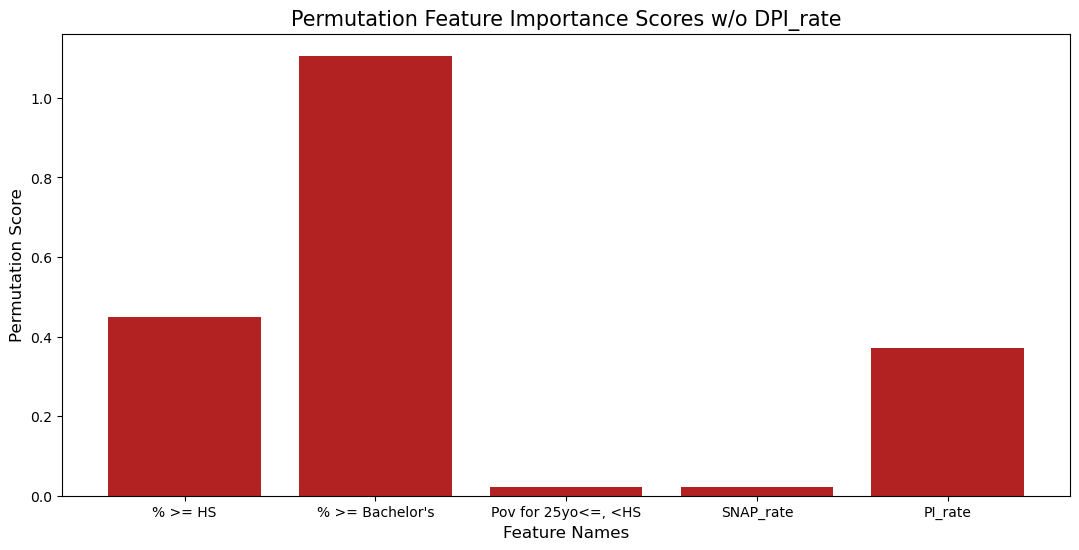

In [22]:
plt.figure(figsize=(13, 6))
plt.bar(feature_importance_df["Feature"], feature_importance_df["Permutation"], color="firebrick")
plt.xlabel("Feature Names", fontsize=12)
plt.ylabel("Permutation Score", fontsize=12)
plt.xticks(fontsize=10)
plt.title("Permutation Feature Importance Scores w/o DPI_rate", fontsize=15)
plt.show()

# Random Forest :)

In [23]:
from sklearn.ensemble import RandomForestRegressor

In [24]:
X = df[["% >= HS", "% >= Bachelor's", "Pov for 25yo<=, <HS", 
                    "SNAP_rate", "PI_rate"]] 
y = df["HFR"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42)

In [25]:
rf = RandomForestRegressor(bootstrap=False, max_depth=10, max_features=0.7,
                      min_samples_leaf=10,
                      min_samples_split=20,
                      n_estimators=np.int64(1136))
rf.fit(X_train, y_train)

# scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')
# print(f"Mean r^2 score accross 5 folds for {rf}: {np.mean(scores):.3f}")
# print(f"All fold scores for {rf}: {scores}\n")

rf.fit(X_train, y_train)
print(rf.score(X_test, y_test))

importance = rf.feature_importances_
D = dict()
for i, v in enumerate(importance):
    D[column_names_list[i]] = v
    print(f'{column_names_list[i]}, Score: {v:.5f}')

0.614404866142719
% >= HS, Score: 0.19087
% >= Bachelor's, Score: 0.43308
Pov for 25yo<=, <HS, Score: 0.02308
SNAP_rate, Score: 0.03334
PI_rate, Score: 0.31963


In [26]:
rf_scores = pd.DataFrame(list(D.items()), columns=['Feature', 'RandomForest'])

In [27]:
importance_df2

,Feature,LinearReg
0,% >= HS,2.402364
1,% >= Bachelor's,1.880572
4,PI_rate,1.279294
3,SNAP_rate,0.866187
2,"Pov for 25yo<=, <HS",0.814288


In [28]:
# single_lr = single_lr.drop(4)

In [29]:
single_lr

,Feature,SingleLinearReg
0,% >= HS,0.009766
1,% >= Bachelor's,0.349129
2,"Pov for 25yo<=, <HS",0.040661
3,SNAP_rate,0.005491
4,PI_rate,0.306898


In [30]:
feature_importance_df

,Feature,Permutation
0,% >= HS,0.450088
1,% >= Bachelor's,1.105856
2,"Pov for 25yo<=, <HS",0.022015
3,SNAP_rate,0.022964
4,PI_rate,0.370231


In [31]:
rf_scores

,Feature,RandomForest
0,% >= HS,0.190868
1,% >= Bachelor's,0.433078
2,"Pov for 25yo<=, <HS",0.023080
3,SNAP_rate,0.033344
4,PI_rate,0.319631


In [32]:
df1 = pd.merge(importance_df2, single_lr, on="Feature")
df1

,Feature,LinearReg,SingleLinearReg
0,% >= HS,2.402364,0.009766
1,% >= Bachelor's,1.880572,0.349129
2,PI_rate,1.279294,0.306898
3,SNAP_rate,0.866187,0.005491
4,"Pov for 25yo<=, <HS",0.814288,0.040661


In [33]:
df2 = pd.merge(df1, feature_importance_df, on="Feature")
df2

,Feature,LinearReg,SingleLinearReg,Permutation
0,% >= HS,2.402364,0.009766,0.450088
1,% >= Bachelor's,1.880572,0.349129,1.105856
2,PI_rate,1.279294,0.306898,0.370231
3,SNAP_rate,0.866187,0.005491,0.022964
4,"Pov for 25yo<=, <HS",0.814288,0.040661,0.022015


In [34]:
all_importance_scores = pd.merge(df2, rf_scores, on="Feature")
all_importance_scores

,Feature,LinearReg,SingleLinearReg,Permutation,RandomForest
0,% >= HS,2.402364,0.009766,0.450088,0.190868
1,% >= Bachelor's,1.880572,0.349129,1.105856,0.433078
2,PI_rate,1.279294,0.306898,0.370231,0.319631
3,SNAP_rate,0.866187,0.005491,0.022964,0.033344
4,"Pov for 25yo<=, <HS",0.814288,0.040661,0.022015,0.023080


In [35]:
all_importance_scores

,Feature,LinearReg,SingleLinearReg,Permutation,RandomForest
0,% >= HS,2.402364,0.009766,0.450088,0.190868
1,% >= Bachelor's,1.880572,0.349129,1.105856,0.433078
2,PI_rate,1.279294,0.306898,0.370231,0.319631
3,SNAP_rate,0.866187,0.005491,0.022964,0.033344
4,"Pov for 25yo<=, <HS",0.814288,0.040661,0.022015,0.023080


In [37]:
df_list = [all_importance_scores[["Feature", "LinearReg"]].sort_values(by='LinearReg', ascending=False).reset_index(drop=True), 
          all_importance_scores[["Feature", "SingleLinearReg"]].sort_values(by='SingleLinearReg', ascending=False).reset_index(drop=True), 
          all_importance_scores[["Feature", "Permutation"]].sort_values(by='Permutation', ascending=False).reset_index(drop=True), 
          all_importance_scores[["Feature", "RandomForest"]].sort_values(by='RandomForest', ascending=False).reset_index(drop=True)]
column_list = ["LinearReg", "SingleLinearReg", "Permutation", "RandomForest"]

In [40]:
def get_rankings(df_list, column_list):
    D = {
        "Features" : ["% >= HS", "% >= Bachelor's", "PI_rate", "SNAP_rate", "Pov for 25yo<=, <HS"], 
        "Scores": [0., 0., 0., 0., 0.]
    }
    ranking_df = pd.DataFrame(D)
    ranking_df = ranking_df.set_index('Features')
    col_idx = 0 
    for df in df_list:
        index = 0 
        place = 4
        for i in range(1, len(df[column_list[col_idx]])):
            prev = df[column_list[col_idx]][index]
            curr = df[column_list[col_idx]][i]
            diff = prev - curr
            place_scale = place + diff
            ranking_df.loc[df["Feature"][index]] += place_scale
            index +=1
            place -= 1
        ranking_df.loc[df["Feature"][index]] += 1
        col_idx += 1
    return ranking_df

In [41]:
rankings = get_rankings(df_list, column_list).sort_values(by="Scores", ascending=False)

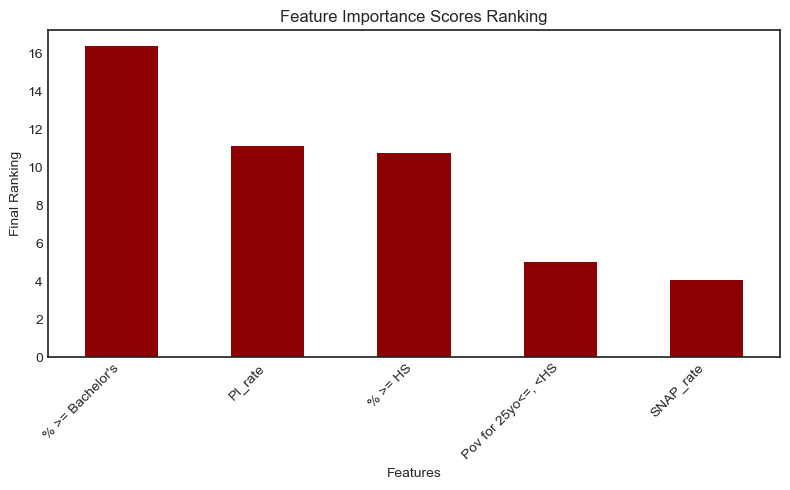

In [46]:
rankings.plot(kind='bar', figsize=(8, 5), color="darkred", legend=False) 
plt.title('Feature Importance Scores Ranking')
plt.ylabel('Final Ranking')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right') 
# plt.legend(title='Value Type')
plt.tight_layout()
plt.show()

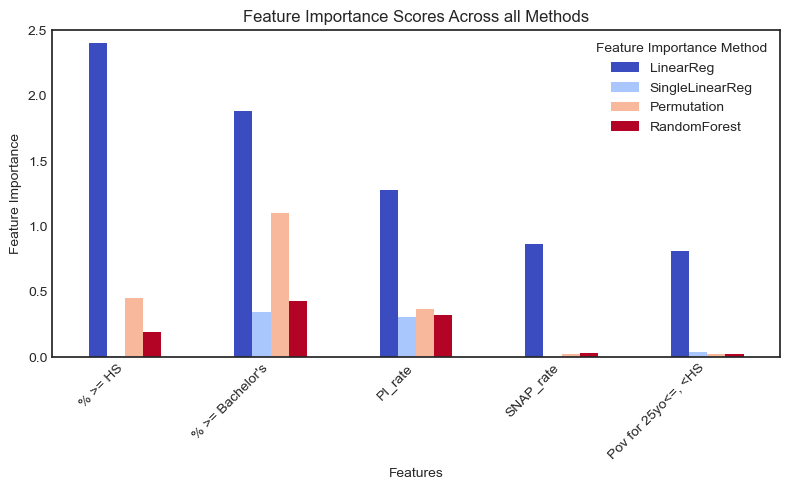

In [45]:
all_importance_scores = all_importance_scores.set_index('Feature')
all_importance_scores.plot(kind='bar', figsize=(8, 5), colormap='coolwarm') 
plt.title('Feature Importance Scores Across all Methods')
plt.ylabel('Feature Importance')
plt.xlabel('Features')
plt.ylim(0, 2.501)
plt.style.use('seaborn-v0_8-white')
plt.xticks(rotation=45, ha='right') 
plt.legend(title='Feature Importance Method')
plt.tight_layout()
plt.show()